# Atmospheric Temperature On Pressure Levels

Create a CMIP7 monthly air temperature file (`ta_tavg-p19-hxy-air`) on the requested 19 pressure levels.

In [ ]:
from pathlib import Path
import calendar
import json
import shutil

import cmor
from IPython.display import display
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
import xarray as xr

TABLES_DIR = "../cmip7-cmor-tables/tables"
CV_PATH = "../cmip7-cmor-tables/tables-cvs/cmor-cvs.json"
DATA_PATH = Path("data") / "ta_Amon_E3SM-3-0_historical_r1i1p1f1_gr_187001-187002.nc"
if not Path(TABLES_DIR).exists():
    raise FileNotFoundError(f"CMIP7 tables directory not found: {TABLES_DIR}")
if not Path(CV_PATH).exists():
    raise FileNotFoundError(f"CMIP7 CV file not found: {CV_PATH}")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Source data file not found: {DATA_PATH}")



def month_year_label(time_coord):
    decoded_time = xr.coding.times.decode_cf_datetime(
        time_coord.values[:1],
        time_coord.attrs["units"],
        calendar=time_coord.attrs.get("calendar", "standard"),
    )[0]
    if hasattr(decoded_time, "strftime"):
        return decoded_time.strftime("%B %Y")
    date_text = np.datetime_as_string(decoded_time, unit="D")
    year, month = date_text.split("-")[:2]
    return f"{calendar.month_name[int(month)]} {year}"


print(f"Using CMIP7 tables from {TABLES_DIR}")


Using CMIP7 tables from ../cmip7-cmor-tables/tables


In [ ]:
with xr.open_dataset(DATA_PATH, decode_times=False) as opened:
    source = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(source)


<xarray.Dataset> Size: 10MB
Dimensions:    (time: 2, bnds: 2, lat: 180, lon: 360, plev: 19)
Coordinates:
  * time       (time) float64 16B 7.316e+03 7.345e+03
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 32B 7.3e+03 7.331e+03 7.331e+03 7.359e+03
    lat_bnds   (lat, bnds) float64 3kB -90.0 -89.0 -89.0 ... 89.0 89.0 90.0
    lon_bnds   (lon, bnds) float64 6kB 0.0 1.0 1.0 2.0 ... 359.0 359.0 360.0
    ta         (time, plev, lat, lon) float32 10MB nan nan nan ... 269.4 269.4
Attributes:
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            CMIP
    branch_method:          standard
    branch_time_in_child:   0.0
    branch_time_in_parent:  18250.0
    creation_date:          2025-08-10T17:00:06Z
    data contact:           E3SM-DATA-SUPPORT@LLNL.GOV
    data_specs_version:     01.00.33
    experiment:             all-forcing simulation of the recent past
    experiment_id:          historical
    external_variables:     areacella
    forcing_index:          1
    frequency:              mon
    further_info_url:       https://furtherinfo.es-doc.org/CMIP6.E3SM-Project...
    grid:                   data regridded to a CMIP6 standard 1x1 degree lon...
    grid_label:             gr
    history:                2025-08-10T17:00:06Z ;rewrote data to be consiste...
    initialization_index:   1
    institution:            LLNL (Lawrence Livermore National Laboratory, Liv...
    institution_id:         E3SM-Project
    label:                  E3SM 3.0
    label_extended:         E3SM 3.0 (Energy Exascale Earth System Model)
    mip_era:                CMIP6
    nominal_resolution:     100 km
    parent_activity_id:     CMIP
    parent_experiment_id:   piControl
    parent_mip_era:         CMIP6
    parent_source_id:       E3SM-3-0
    parent_time_units:      days since 0001-01-01
    parent_variant_label:   r1i1p1f1
    physics_index:          1
    product:                model-output
    project PI:             Dr. Peter Caldwell (caldwell19@llnl.gov), Dr. Dav...
    realization_index:      1
    realm:                  atmos
    references:             Xie, S., and co-authors, 2025: The Energy Exascal...
    release_year:           2024
    source:                 E3SM 3.0 (2025): \naerosol: MAM5 w/ prognostic st...
    source_id:              E3SM-3-0
    source_type:            AOGCM AER
    sub_experiment:         none
    sub_experiment_id:      none
    table_id:               Amon
    table_info:             Creation Date:(18 November 2020) MD5:4945869d85ef...
    title:                  E3SM-3-0 output prepared for CMIP6
    tracking_id:            hdl:21.14100/e908eefe-4329-4f97-9de6-8b2dd3a78be0
    variable_id:            ta
    variant_label:          r1i1p1f1
    version:                v20250810
    license:                CMIP6 model data produced by E3SM-Project is lice...
    cmor_version:           3.11.0

In [ ]:
run_dir = Path("output") / "03_pressure_level_air_temperature"
if run_dir.exists():
    shutil.rmtree(run_dir)
output_dir = run_dir / "cmor_output"
output_dir.mkdir(parents=True)

DATASET_INFO = {
    "_AXIS_ENTRY_FILE": "CMIP7_coordinate.json",
    "_FORMULA_VAR_FILE": "CMIP7_formula_terms.json",
    "_cmip7_option": 1,
    "_controlled_vocabulary_file": CV_PATH,
    "activity_id": "CMIP",
    "calendar": source["time"].attrs.get("calendar", "standard"),
    "experiment_id": "amip",
    "forcing_index": "f3",
    "frequency": "mon",
    "grid_label": "g999",
    "host_collection": "CMIP7",
    "initialization_index": "i1",
    "institution_id": "CCCma",
    "license_id": "CC-BY-4.0",
    "nominal_resolution": "100 km",
    "outpath": str(output_dir),
    "physics_index": "p1",
    "realization_index": "r9",
    "region": "glb",
    "source_id": "DUMMY-MODEL",
}
input_json = run_dir / "input.json"
input_json.write_text(json.dumps(DATASET_INFO, indent=2, sort_keys=True))

lat = source["lat"].values.astype("f8")
lat_bnds = source["lat_bnds"].values.astype("f8")
lon = source["lon"].values.astype("f8")
lon_bnds = source["lon_bnds"].values.astype("f8")
time = source["time"].values.astype("f8")
time_bnds = source["time_bnds"].values.astype("f8")
time_units = source["time"].attrs["units"]
plev = source["plev"].values.astype("f8")
plev_units = source["plev"].attrs.get("units", "Pa")

missing_value = np.float32(1.0e20)
ta_source = source["ta"].values.astype("f4")
ta = np.where(np.isfinite(ta_source), ta_source, missing_value).astype("f4")

print(ta.shape)


(2, 19, 180, 360)


In [ ]:
cmor.setup(
    inpath=TABLES_DIR,
    netcdf_file_action=cmor.CMOR_REPLACE,
    logfile=str(run_dir / "cmor.log"),
)
cmor.dataset_json(str(input_json))
cmor.load_table("CMIP7_atmos.json")

time_id = cmor.axis("time", coord_vals=time, cell_bounds=time_bnds, units=time_units)
plev_id = cmor.axis("plev19", coord_vals=plev, units=plev_units)
lat_id = cmor.axis("latitude", coord_vals=lat, cell_bounds=lat_bnds, units="degrees_north")
lon_id = cmor.axis("longitude", coord_vals=lon, cell_bounds=lon_bnds, units="degrees_east")

variable_name = "ta_tavg-p19-hxy-air"
ta_id = cmor.variable(variable_name, "K", [time_id, plev_id, lat_id, lon_id], missing_value=missing_value)
compound_name = ".".join(["atmos"] + variable_name.split("_") + ["mon", "glb"])

with open(Path(TABLES_DIR) / "CMIP7_cell_measures.json") as handle:
    cell_measure = json.load(handle)["cell_measures"].get(compound_name)
if cell_measure:
    cmor.set_variable_attribute(ta_id, "cell_measures", "c", cell_measure)

with open(Path(TABLES_DIR) / "CMIP7_long_name_overrides.json") as handle:
    long_name = json.load(handle)["long_name_overrides"].get(compound_name)
if long_name:
    cmor.set_variable_attribute(ta_id, "long_name", "c", long_name)

cmor.write(ta_id, ta)
netcdf_path = Path(cmor.close(ta_id, file_name=True))
cmor.close()

print(netcdf_path.resolve().relative_to(Path.cwd().resolve()))


output/03_pressure_level_air_temperature/cmor_output/MIP-DRS7/CMIP7/CMIP/CCCma/DUMMY-MODEL/amip/r9i1p1f3/glb/mon/ta/tavg-p19-hxy-air/g999/v20260624/ta_tavg-p19-hxy-air_mon_glb_g999_DUMMY-MODEL_amip_r9i1p1f3_187001-187002.nc


In [ ]:
with xr.open_dataset(netcdf_path, decode_times=False) as opened:
    ds = opened.load()

with xr.set_options(
    display_style="html",
    display_expand_attrs=True,
    display_expand_coords=True,
    display_expand_data_vars=True,
    display_max_rows=80,
):
    display(ds)

<xarray.Dataset> Size: 10MB
Dimensions:    (time: 2, bnds: 2, lat: 180, lon: 360, plev: 19)
Coordinates:
  * time       (time) float64 16B 7.316e+03 7.345e+03
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon        (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * plev       (plev) float64 152B 1e+05 9.25e+04 8.5e+04 ... 1e+03 500.0 100.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) float64 32B 7.3e+03 7.331e+03 7.331e+03 7.359e+03
    lat_bnds   (lat, bnds) float64 3kB -90.0 -89.0 -89.0 ... 89.0 89.0 90.0
    lon_bnds   (lon, bnds) float64 6kB 0.0 1.0 1.0 2.0 ... 359.0 359.0 360.0
    ta         (time, plev, lat, lon) float32 10MB nan nan nan ... 269.4 269.4
Attributes:
    Conventions:           CF-1.12
    activity_id:           CMIP
    area_label:            air
    branded_variable:      ta_tavg-p19-hxy-air
    branding_suffix:       tavg-p19-hxy-air
    creation_date:         2026-06-25T00:02:47Z
    data_specs_version:    MIP-DS7.1.0.0
    description:           Simulation of the climate of the recent past with ...
    drs_specs:             MIP-DRS7
    experiment:            Simulation of the climate of the recent past with ...
    experiment_id:         amip
    external_variables:    areacella
    forcing_index:         f3
    frequency:             mon
    grid_label:            g999
    history:               2026-06-25T00:02:47Z ; CMOR rewrote data to be con...
    horizontal_label:      hxy
    host_collection:       CMIP7
    initialization_index:  i1
    institution:           Environment and Climate Change Canada
    institution_id:        CCCma
    license_id:            CC-BY-4.0
    mip_era:               CMIP7
    nominal_resolution:    100 km
    physics_index:         p1
    product:               model-output
    realization_index:     r9
    realm:                 atmos
    region:                glb
    source:                DUMMY-MODEL: aerosol: Dummy Aerosol; atmosphere: D...
    source_id:             DUMMY-MODEL
    table_info:            Name: CMIP7_atmos.json; Creation Date:(2026-06-22 ...
    temporal_label:        tavg
    title:                 DUMMY-MODEL output prepared for CMIP7
    tracking_id:           hdl:21.14107/c433330a-69cb-4ac2-b727-6a20a63bfd5e
    variable_id:           ta
    variant_label:         r9i1p1f3
    vertical_label:        p19
    license:               CC-BY-4.0; CMIP7 data produced by CCCma is license...
    cmor_version:          3.15.1

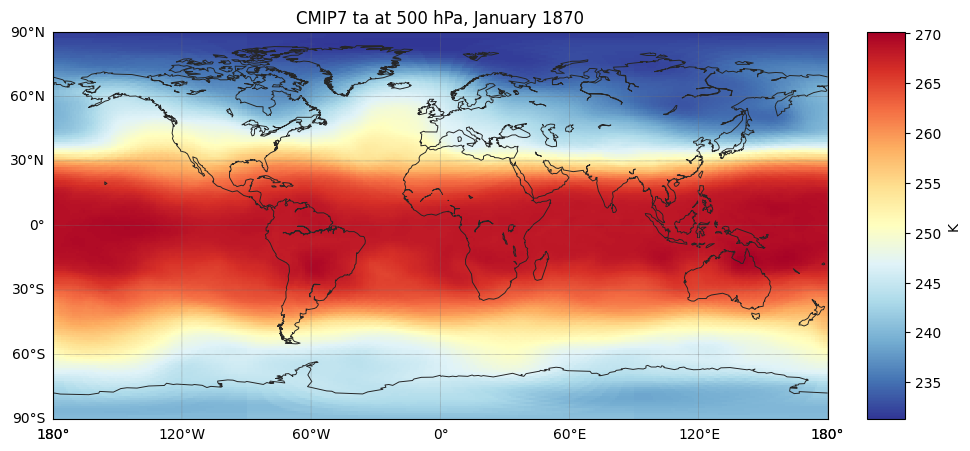

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5.4))
map_plot = Basemap(
    projection="cyl",
    llcrnrlon=-180,
    urcrnrlon=180,
    llcrnrlat=-90,
    urcrnrlat=90,
    resolution="c",
    ax=ax,
)
map_plot.drawmapboundary(fill_color="#f7fbff", linewidth=0.8)
lon_wrapped = ((ds["lon"].values + 180.0) % 360.0) - 180.0
lon_order = np.argsort(lon_wrapped)
lon_grid, lat_grid = np.meshgrid(lon_wrapped[lon_order], ds["lat"].values)
x, y = map_plot(lon_grid, lat_grid)
field = ds["ta"].sel(plev=50000.0).isel(time=0).values[:, lon_order]
mesh = map_plot.pcolormesh(x, y, field, shading="auto", cmap="RdYlBu_r")
map_plot.drawcoastlines(linewidth=0.7, color="0.15")
map_plot.drawparallels(np.arange(-90, 91, 30), labels=[1, 0, 0, 0], linewidth=0.4, color="0.45", dashes=[1, 1])
map_plot.drawmeridians(np.arange(-180, 181, 60), labels=[0, 0, 0, 1], linewidth=0.4, color="0.45", dashes=[1, 1])
colorbar = map_plot.colorbar(mesh, location="right", pad="5%")
colorbar.set_label("K")
time_label = month_year_label(ds["time"])
ax.set_title(f"CMIP7 ta at 500 hPa, {time_label}")
plt.show()
